# 03 — Probabilistic Generative Models

## 📚 Learning Objectives

By completing this notebook, you will:
- Fit a **latent-variable generative model** — a Gaussian Mixture Model (GMM) — by maximum likelihood
- Use **held-out log-likelihood** to evaluate and select between generative models
- **Sample new data** from a fitted probabilistic model and compare it with the real data

## 🔗 Where this fits

**Builds on:** Course 03 (AIAT 113) — Unit 5, lesson 06 "Maximum Likelihood Estimation" — a GMM is MLE with a latent variable, and Course 04 (AIAT 114) — Unit 4, lesson 01, since k-means is a hard-assignment special case of it.

**Used later in:** Course 10 — Unit 1, lesson 04, where the latent variable stops being a cluster label and becomes a learned vector.

---

## Introduction

A **probabilistic generative model** writes down p(x) explicitly and fits it by **maximizing likelihood**. The simplest interesting one is the **Gaussian Mixture Model**:

p(x) = Σₖ p(z = k) · p(x | z = k),  with each p(x|z=k) a Gaussian.

Here `z` is a **latent variable** — "which component produced this point?" — which we never observe. This is exactly the structure a VAE (example 04) scales up: the VAE replaces the K discrete components with a continuous latent vector and the Gaussians with neural networks, and maximizes a lower bound (ELBO) on this same log-likelihood.

---

## 🌍 Why this lesson exists — GMM speaker verification, the NIST evaluations

The Gaussian mixture you are about to fit is not a teaching toy. **GMM-UBM speaker verification** (Reynolds, Quatieri & Dunn, 2000, *Digital Signal Processing* 10) fitted a Gaussian mixture over spectral features of speech and scored a claimed speaker by likelihood ratio against a universal background model. It was the reference system in the NIST Speaker Recognition Evaluations for roughly a decade, and it is exactly the three moves in this notebook: fit a density, score likelihood, decide. The features were voices instead of petals; the mathematics was this.

**What goes wrong without this:** without a density you can only ask "which of my known classes is this closest to?" You cannot ask "how surprising is this?" — and fraud detection, intrusion detection, equipment monitoring and speaker verification are all the second question. A classifier forced to answer it will confidently assign every impostor to whichever enrolled speaker they happen to resemble most.


## Fitting and Comparing Models

We fit GMMs with 1–5 components on the real petal measurements and score each in two ways:

- **Held-out log-likelihood** — how much probability the model assigns to *unseen* real flowers (higher = better). This is the standard way to compare probabilistic generative models.
- **BIC** (Bayesian Information Criterion) — likelihood *minus a penalty for model size* (lower = better). Useful because held-out likelihood often keeps creeping up slightly as you add components; BIC asks whether the extra components pay for themselves.

The species labels stay in a locked drawer: the GMM is fitted on the measurements alone. Only after selection do we check the chosen K against the three species that are actually in the data.


In [1]:
# WHAT/WHY: fit Gaussian Mixture Models with different numbers of components
# on REAL flower measurements, then use held-out log-likelihood and BIC to
# choose the best model — demonstrating that likelihood is both the training
# signal and the yardstick. The iris data contains three real species, so the
# selected K can be checked against a ground truth the model never saw.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

# ── REAL DATA: Anderson's iris measurements (150 flowers, 1935) ───────────
# We keep two of the four real features so the density is easy to plot.
iris = load_iris()
X = iris.data[:, 2:4]                      # petal length, petal width (cm)
y_true = iris.target                       # species labels — NOT given to the GMM
FEAT = [iris.feature_names[2], iris.feature_names[3]]
print(f'Real dataset: {X.shape[0]} iris flowers, features = {FEAT}')
print(f'Species actually present: {dict(zip(iris.target_names, np.bincount(y_true)))}')
print(f'petal length range: {X[:,0].min():.1f}–{X[:,0].max():.1f} cm | '
      f'petal width range: {X[:,1].min():.1f}–{X[:,1].max():.1f} cm')

X_tr, X_te, y_tr, y_te = train_test_split(X, y_true, test_size=0.3, random_state=0)
print(f'train: {len(X_tr)} flowers | held-out: {len(X_te)} flowers')

# ── Fit K = 1..5; score held-out log-likelihood AND BIC for each ──────────
# Held-out LL rewards fit to unseen data; BIC additionally penalizes model
# size, guarding against "one more component always helps a little".
print("\nK   held-out avg log-likelihood      BIC (lower = better)")
ll, bic = {}, {}
for k in range(1, 6):
    gmm = GaussianMixture(n_components=k, random_state=0).fit(X_tr)
    ll[k]  = gmm.score(X_te)     # mean log p(x) per held-out flower
    bic[k] = gmm.bic(X_tr)       # Bayesian Information Criterion on train
    print(f"{k}          {ll[k]:+.4f}                {bic[k]:,.1f}")

# ── Select K (computed, not assumed) ──────────────────────────────────────
best_k   = min(bic, key=bic.get)
best_k_ll = max(ll, key=ll.get)
print(f"\nBIC selects K = {best_k}; held-out log-likelihood also peaks at K = {best_k_ll}.")
print(f"The data really does contain {len(iris.target_names)} species "
      f"({', '.join(iris.target_names)}) — and the model recovered that count")
print("from the measurements alone, without ever seeing a label.")
gmm = GaussianMixture(n_components=best_k, random_state=0).fit(X_tr)


Real dataset: 150 iris flowers, features = ['petal length (cm)', 'petal width (cm)']
Species actually present: {np.str_('setosa'): np.int64(50), np.str_('versicolor'): np.int64(50), np.str_('virginica'): np.int64(50)}
petal length range: 1.0–6.9 cm | petal width range: 0.1–2.5 cm
train: 105 flowers | held-out: 45 flowers

K   held-out avg log-likelihood      BIC (lower = better)
1          -1.9298                396.8
2          -1.3260                250.2
3          -1.2838                247.1
4          -1.3618                256.8
5          -1.3814                271.1

BIC selects K = 3; held-out log-likelihood also peaks at K = 3.
The data really does contain 3 species (setosa, versicolor, virginica) — and the model recovered that count
from the measurements alone, without ever seeing a label.


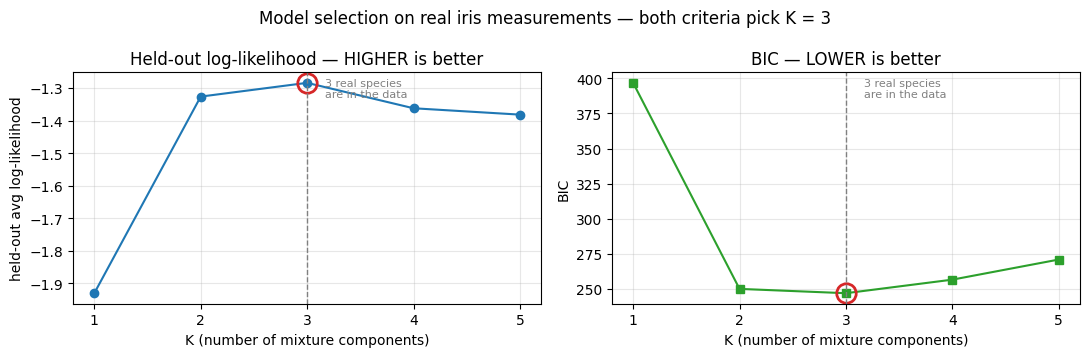

In [2]:
# WHAT/WHY: draw the selection table above instead of only printing it. Both
# criteria are plotted against K so the choice is visible as a shape, not read
# off six numbers. Nothing is recomputed here — these are the same ll/bic dicts.
Ks = sorted(ll)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].plot(Ks, [ll[k] for k in Ks], 'o-', color='tab:blue')
axes[0].plot(best_k_ll, ll[best_k_ll], 'o', ms=14, mfc='none', mec='tab:red', mew=2)
axes[0].set_xlabel('K (number of mixture components)')
axes[0].set_ylabel('held-out avg log-likelihood')
axes[0].set_title('Held-out log-likelihood — HIGHER is better')
axes[0].set_xticks(Ks); axes[0].grid(alpha=0.3)

axes[1].plot(Ks, [bic[k] for k in Ks], 's-', color='tab:green')
axes[1].plot(best_k, bic[best_k], 'o', ms=14, mfc='none', mec='tab:red', mew=2)
axes[1].set_xlabel('K (number of mixture components)')
axes[1].set_ylabel('BIC')
axes[1].set_title('BIC — LOWER is better')
axes[1].set_xticks(Ks); axes[1].grid(alpha=0.3)

for ax in axes:                       # the ground truth the model never saw
    ax.axvline(3, color='grey', ls='--', lw=1)
    # Put the label at the TOP of each panel: the circled best-K marker sits low
    # in the BIC panel, and a bottom-anchored label would land on top of it.
    ax.annotate('3 real species\nare in the data', xy=(3, 1), xycoords=('data', 'axes fraction'),
                xytext=(13, -4), textcoords='offset points',
                fontsize=8, color='grey', ha='left', va='top')
plt.suptitle(f'Model selection on real iris measurements — both criteria pick K = {best_k}')
plt.tight_layout(); plt.show()

**Read the two curves.** The left panel rises steeply from K = 1 to K = 3 and then *falls*: adding a fourth component makes the model fit **unseen** flowers worse, which is overfitting caught by held-out data rather than by opinion. The right panel does the same thing upside down — BIC drops to its minimum and then climbs as the size penalty starts to outweigh the extra likelihood.

Both circled points sit on the dashed line marking the three species that are genuinely in the data, and the model was never shown a species label. Note also how *shallow* the curves are between K = 2 and K = 3 compared with the drop from K = 1: that flatness is the honest reason discussion question 3 below is a real question and not a formality.

## How the Fit Actually Happens — EM, Step by Step

`GaussianMixture(...).fit()` hides an iterative algorithm: **Expectation-Maximization**. Each iteration does two things — E-step: given the current Gaussians, compute each flower's probability of belonging to each component; M-step: given those soft assignments, re-fit each Gaussian's mean and covariance. Repeat until the log-likelihood stops improving.

The storyboard below is that loop, frozen at six iterations. To make the movement visible we start it from a deliberately bad initialisation (`init_params='random'`, which begins with random assignments, so all three components start piled on top of each other at the centre of the data). The model fitted above used scikit-learn's default k-means initialisation, which starts much closer to the answer.

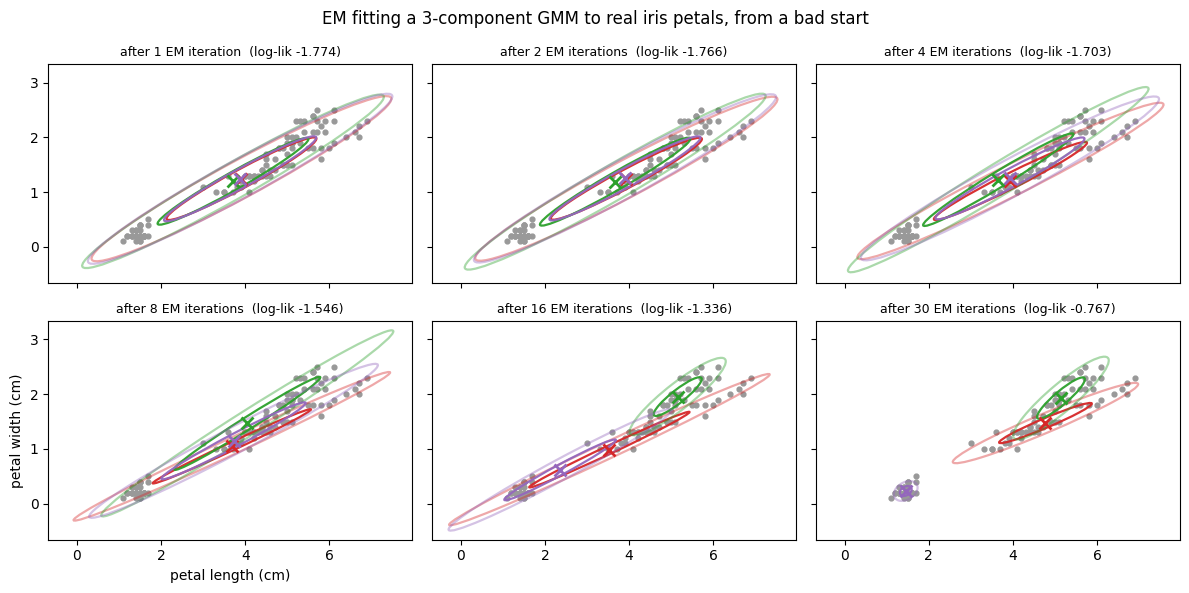

iteration   train log-likelihood   component centres (petal length, width)
     1      -1.7739            (3.71, 1.20)  (3.88, 1.24)  (3.91, 1.25)
     2      -1.7659            (3.67, 1.19)  (3.90, 1.25)  (3.93, 1.24)
     4      -1.7032            (3.65, 1.23)  (3.93, 1.25)  (3.94, 1.20)
     8      -1.5463            (3.68, 1.05)  (3.72, 1.15)  (4.05, 1.47)
    16      -1.3357            (2.36, 0.62)  (3.53, 0.99)  (5.15, 1.96)
    30      -0.7670            (1.45, 0.23)  (4.77, 1.47)  (5.14, 1.93)


In [3]:
# WHAT/WHY: a frame-grid storyboard of EM. Each panel refits the SAME model
# from the SAME initialisation but is stopped after a different number of
# iterations, so the six panels are six snapshots of one run. Ellipses are the
# 1- and 2-sigma contours of each fitted Gaussian; the printed table beside them
# reports the train log-likelihood EM is climbing.
import warnings
from matplotlib.patches import Ellipse

SNAPSHOT_ITERS = [1, 2, 4, 8, 16, 30]
frames = []
for n_it in SNAPSHOT_ITERS:
    with warnings.catch_warnings():
        # max_iter=1..16 is deliberately stopped early, so ignore the expected
        # "did not converge" warning — non-convergence is the point of the frame.
        warnings.simplefilter("ignore")
        g = GaussianMixture(n_components=best_k, random_state=1, max_iter=n_it,
                            init_params='random', tol=0).fit(X_tr)
    frames.append((n_it, g.means_.copy(), g.covariances_.copy(), g.score(X_tr)))

def draw_component(ax, mean, cov, color):
    """Draw the 1-sigma and 2-sigma ellipses of one fitted Gaussian."""
    vals, vecs = np.linalg.eigh(cov)                 # principal axes of the Gaussian
    angle = np.degrees(np.arctan2(vecs[1, -1], vecs[0, -1]))
    for n_std, alpha in [(1, 0.95), (2, 0.4)]:
        w, h = 2 * n_std * np.sqrt(vals[::-1])
        ax.add_patch(Ellipse(mean, w, h, angle=angle, fill=False,
                             edgecolor=color, lw=1.6, alpha=alpha, zorder=4))
    ax.plot(*mean, marker='x', color=color, ms=8, mew=2, zorder=5)

colors = ['tab:red', 'tab:green', 'tab:purple']
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey=True)
for ax, (n_it, means, covs, score) in zip(axes.flat, frames):
    ax.scatter(X_tr[:, 0], X_tr[:, 1], s=12, c='0.6', zorder=1)
    for k in range(len(means)):
        draw_component(ax, means[k], covs[k], colors[k % len(colors)])
    ax.set_title(f"after {n_it} EM iteration{'s' if n_it > 1 else ''}  "
                 f"(log-lik {score:+.3f})", fontsize=9)
axes[1, 0].set_xlabel(FEAT[0]); axes[1, 0].set_ylabel(FEAT[1])
plt.suptitle("EM fitting a 3-component GMM to real iris petals, from a bad start")
plt.tight_layout(); plt.show()

# ── Printed step table beside the storyboard ──────────────────────────────
print("iteration   train log-likelihood   component centres (petal length, width)")
for n_it, means, _, score in frames:
    centres = "  ".join(f"({m[0]:.2f}, {m[1]:.2f})" for m in means[means[:, 0].argsort()])
    print(f"{n_it:>6}      {score:+.4f}            {centres}")

**Read the storyboard.** In the first panel all three ellipses sit on top of one another in the middle of the data — the random start gave every component almost the same mean, so the mixture is effectively one fat Gaussian and the log-likelihood is at its worst. Panel by panel the components pull apart: one breaks away toward the small-petal group at the bottom left (the setosa flowers), and the remaining two divide the large-petal cloud between them. The printed log-likelihood rises at every snapshot — that is EM's guarantee, and it is the same "maximize likelihood" objective the K-selection table used, now visible as motion instead of as a number.

Two lessons live in this picture. First, **the answer is a fixed point of an iterative process, not a formula** — which is why a bad initialisation can strand the components in the wrong place, and why scikit-learn runs k-means first by default. Second, the ellipses are what the model *is*: an explicit p(x) you can evaluate and sample, which is what the next cell does.

## Part 2 — Generate New Data From the Fitted Model

A fitted probabilistic model is a **generator**: sampling means (1) draw the latent component `z` from its learned weights, then (2) draw x from that component's Gaussian. We plot real vs generated points over the model's learned density.


Samples drawn per latent component z: [62, 64, 74]
Generated petal length: mean 3.88 cm, std 1.82   (real held-out: mean 3.59, std 1.66)
Generated petal width : mean 1.24 cm, std 0.78   (real held-out: mean 1.13, std 0.71)

Physically impossible samples (a negative measurement): 1/200 = 0.5%
The model knows nothing about botany, only about Gaussians.


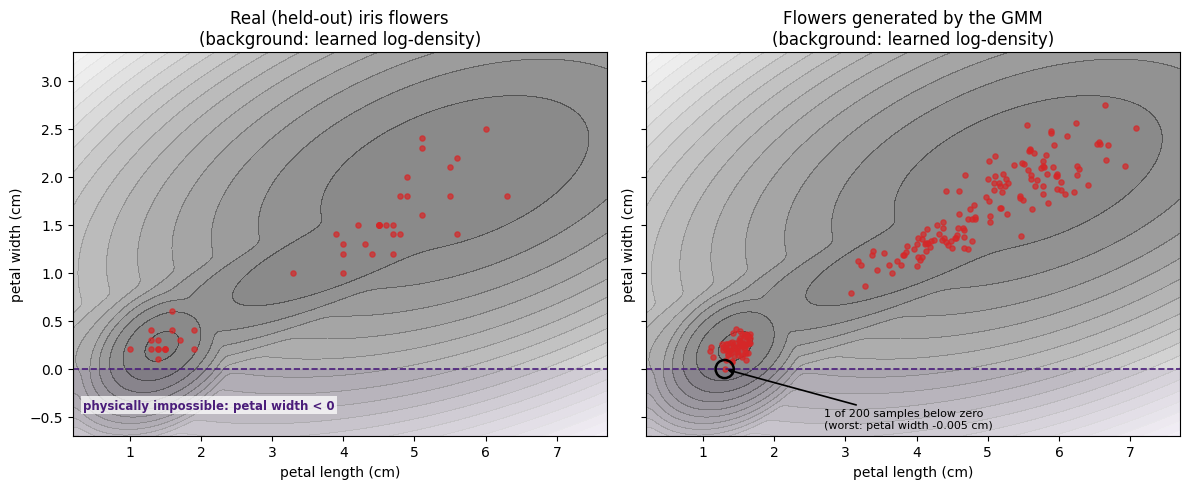


Sampling procedure: draw latent z ~ learned weights, then x ~ Gaussian(z).
A VAE (example 04) does exactly this with a continuous z and neural networks.


In [4]:
# WHAT/WHY: sample brand-new flowers from the fitted GMM and compare them with
# the real held-out measurements on top of the model's learned density — the
# visual test of a generative model: do its samples look like the data?

# ── Sample 200 new points; .sample also returns each point's latent z ─────
X_new, z_new = gmm.sample(200)
counts = np.bincount(z_new, minlength=gmm.n_components)
print("Samples drawn per latent component z:", counts.tolist())
print(f"Generated petal length: mean {X_new[:,0].mean():.2f} cm, std {X_new[:,0].std():.2f}"
      f"   (real held-out: mean {X_te[:,0].mean():.2f}, std {X_te[:,0].std():.2f})")
print(f"Generated petal width : mean {X_new[:,1].mean():.2f} cm, std {X_new[:,1].std():.2f}"
      f"   (real held-out: mean {X_te[:,1].mean():.2f}, std {X_te[:,1].std():.2f})")

# ── Honesty check that only real data can give you ────────────────────────
# A Gaussian has infinite support, so the model can generate a NEGATIVE petal
# width - physically impossible for a flower. Count how often that happens.
impossible = int((X_new < 0).any(axis=1).sum())
print(f"\nPhysically impossible samples (a negative measurement): "
      f"{impossible}/{len(X_new)} = {impossible/len(X_new):.1%}")
print("The model knows nothing about botany, only about Gaussians.")

# ── Evaluate the learned density p(x) on a grid for the background ────────
pad = 0.8
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-pad, X[:,0].max()+pad, 200),
                     np.linspace(X[:,1].min()-pad, X[:,1].max()+pad, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
log_dens = gmm.score_samples(grid).reshape(xx.shape)  # log p(x) at each grid point

# ── Plot: real data (left) vs generated data (right), same density map ────
# The shaded band below zero is the PHYSICALLY IMPOSSIBLE region: no flower has
# a negative petal width. It is drawn on both panels so you can see that no real
# flower is ever in it — and that the model put a sample there anyway.
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, pts, title in [(axes[0], X_te, "Real (held-out) iris flowers"),
                       (axes[1], X_new, "Flowers generated by the GMM")]:
    ax.contourf(xx, yy, log_dens, levels=20, cmap="Greys", alpha=0.5)
    ax.scatter(pts[:, 0], pts[:, 1], s=14, alpha=0.7, c="tab:red", label="flowers")
    ax.axhspan(yy.min(), 0, color="tab:purple", alpha=0.18, zorder=0)
    ax.axhline(0, color="#4a1d7a", lw=1.2, ls="--")
    ax.set_xlabel(FEAT[0]); ax.set_ylabel(FEAT[1])
    ax.set_title(title + "\n(background: learned log-density)")
# Label the band once, on the left panel — the right panel gets the sample callout.
axes[0].text(xx.min() + 0.15, -0.38, "physically impossible: petal width < 0",
             fontsize=8.5, color="#4a1d7a", va="center", fontweight="bold",
             bbox=dict(fc="white", ec="none", alpha=0.75, pad=1.5))

# Ring every generated sample that fell into the impossible region and label the
# worst one with its actual value, so the printed count has a place on the plot.
bad = X_new[(X_new < 0).any(axis=1)]
if len(bad):
    axes[1].scatter(bad[:, 0], bad[:, 1], s=170, facecolors="none",
                    edgecolors="black", linewidths=1.8, zorder=5)
    worst = bad[bad[:, 1].argmin()]
    axes[1].annotate(f"{len(bad)} of {len(X_new)} samples below zero\n"
                     f"(worst: petal width {worst[1]:+.3f} cm)",
                     xy=(worst[0], worst[1]), xytext=(worst[0] + 1.4, -0.62),
                     fontsize=8, color="black",
                     arrowprops=dict(arrowstyle="->", lw=1.2, color="black"))
plt.tight_layout(); plt.show()

print("\nSampling procedure: draw latent z ~ learned weights, then x ~ Gaussian(z).")
print("A VAE (example 04) does exactly this with a continuous z and neural networks.")


**Read the figure.** Both panels share one density map — the grey background is the p(x) the GMM fitted — so the only difference between them is which red points are drawn on top.

*Left:* 45 real held-out flowers the model never saw during fitting. They fall into the two dark high-density regions: one tight blob near (1.5, 0.2) and one long diagonal cloud from about (3, 1) to (6, 2.5).

*Right:* 200 flowers the model invented. They occupy the same two regions, in roughly the same proportion — which is the whole claim of a generative model: the samples are indistinguishable in *shape* from the real thing. Look closely and they hug the dark contours a little more tightly than the real flowers do, because sampling a Gaussian puts most points near its centre while real data is scrappier at the edges.

*The purple band* is the honesty check the printed count refers to. No real flower can be in it — petal width cannot be negative — and none is. The GMM put one sample there anyway, ringed in black: a petal width of −0.005 cm. The violation is tiny here only because the setosa component happens to sit close to zero with a small variance; the model has no concept of "impossible", so nothing stops a wider component from producing a badly negative flower. This is the difference between a density that *describes* your data and a model that *understands* it.

## 💬 Discuss

1. BIC and held-out log-likelihood both chose **K = 3**, and iris genuinely contains three species. Would you accept a selected K as "the number of real groups" on a dataset where you had no labels to check against? What else would you demand before reporting that number to a client?
2. The model generated a **negative petal width in 1 of 200 samples (0.5%)**. Name one application where a generator producing 0.5% physically impossible output is perfectly acceptable, and one where it is disqualifying. What makes the difference?
3. Suppose BIC had selected K = 2 while the botanists insist on three species. Which do you trust, and what exactly do you say to the botanist? (Note that the held-out log-likelihood differences between K = 2 and K = 3 above are small: −1.3260 vs −1.2838.)


## From GMM to VAE

| | GMM (this notebook) | VAE (example 04) |
|---|---|---|
| Latent variable | discrete z ∈ {1..K} | continuous vector z |
| p(x\|z) | fixed-form Gaussian | neural network decoder |
| Inference | exact (EM algorithm) | learned encoder + reparameterization |
| Objective | exact log-likelihood | ELBO (a lower bound on log-likelihood) |

Keep the held-out log-likelihood idea in mind: it returns in example 10 as the basis of evaluation metrics for generative models.


## ⚠️ Where this breaks

**Gaussians have infinite support, and it shows.** The fitted model assigns probability to negative measurements and duly produced one — printed above as 1/200 impossible samples. Any bounded, non-negative, discrete or censored quantity (counts, prices, durations, ages) will hit this. The fix is to transform the variable (log, logit) or choose a density with the right support, never to hope the tail does not get sampled.

**BIC's penalty rests on assumptions you often violate.** It assumes the model family contains the truth and that samples are independent. On 105 independent flowers it is a reasonable guide; on clustered, repeated-measure or non-Gaussian data it happily overshoots, and the "elbow" you read off the table is an artefact of the penalty, not of the data.

**A GMM does not scale to images or text.** Fixed-form Gaussians in pixel space are hopeless — which is why example 04 replaces the fixed-form p(x|z) with a neural decoder and pays for that with a *lower bound* instead of an exact likelihood.

**Cheaper alternative:** if you only need groups, and will never sample or score likelihood, k-means answers the same question at a fraction of the cost. Fit the density only when you need what the density buys.


## 📚 References & Further Reading

**Textbooks:**
- Bishop (2006) — *Pattern Recognition and Machine Learning*, Ch. 9 (Mixture Models and EM)
- Goodfellow, Bengio & Courville (2016) — [Deep Learning Book](https://www.deeplearningbook.org/), Ch. 20 (Deep Generative Models)

**Papers:**
- Kingma & Welling (2014) — [Auto-Encoding Variational Bayes](https://arxiv.org/abs/1312.6114) *(the VAE — the deep version of this notebook's idea)*

**Survey:**
- Bond-Taylor et al. (2021) — [Deep Generative Modelling: A Comparative Review](https://arxiv.org/abs/2103.04922) *(where mixture models sit in the modern generative landscape)*

**Recent (2024–2026):**
- Zhai et al. (2024) — [Normalizing Flows are Capable Generative Models](https://arxiv.org/abs/2412.06329) *(the same contract as this notebook's GMM — fit an explicit likelihood, then sample it — scaled up to images)*
- Lipman et al. (2024) — [Flow Matching Guide and Code](https://arxiv.org/abs/2412.06264) *(continuous-time density models: where the "latent z, then a density over x" idea goes next)*


## 📝 Summary

In this notebook you fitted a **Gaussian Mixture Model** — a genuine latent-variable generative model — by maximum likelihood on **real iris petal measurements**, compared models with **held-out log-likelihood and BIC**, and **sampled new flowers** from the fitted model.

Read the printed table: both criteria select **K = 3**, and the iris data really does contain three species. The model recovered the number of real groups from the measurements alone, with the labels never shown to it — a claim you can only make on data whose structure you did not put there yourself.

Then read the honesty check below the samples: a Gaussian has infinite support, so the fitted model happily generates flowers with a *negative* petal width. Its density is a good description of the data and still assigns probability to the impossible. Real measurements make that limitation visible; an invented Gaussian cloud centred far from zero would have concealed it.

These are the same three moves (fit p(x), evaluate likelihood, sample) that every deep generative model in this course repeats at scale.
